

# Project Data Science
***Auteurs : DIALLO Bintou, RIPOLL Thomas***

***Thématique Business:***

Fidélisation et anticipation de la perte de clientèle dans les télécoms

***Contexte métier:*** 

Telco est une entreprise de télécommunications qui fournit des services essentiels de téléphonie et d'accès à internet. Son rôle principal est d'assurer une connectivité fiable tout en accompagnant ses abonnés au quotidien. À travers son service client, elle se charge de résoudre d'éventuelles pannes techniques et de gérer toutes les demandes liées aux abonnements, aux équipements ou à la facturation.

***Jeu de données:***

* **Source de données :** [Kaggle.com](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
* **Nom du dataset :** `WA_Fn-UseC_-Telco-Customer-Churn`
* **Volume :** 977,5 Ko, 7 043 lignes
* **Variables :** 23 variables au total (String : 12, Boolean : 5, Integer : 2, Other : 2). Ces variables se divisent en trois grandes catégories :
    * **Données démographiques :** Sexe, âge, situation familiale.
    * **Services souscrits :** Téléphone, lignes multiples, internet, sécurité en ligne, support technique, streaming, etc.
    * **Informations de compte :** Ancienneté du client, type de contrat, méthode de paiement, facturation mensuelle et totale.

***Problématique business:***

Nous sommes Data Scientist au sein d’une entreprise de télécommunication Telco. Notre entreprise souhaiterais prévoir les moments où les clients seraient les plus à même de résilier leurs abonnements et services souscrits au sein de notre entreprise, afin de savoir quand leur proposer des offres, ou mettre en place différentes techniques marketing pour de les fidéliser de nouveau, et éviter qu’ils ne se désabonnent. Parvenir à prédire ceci permettrait à l’entreprise d’éviter une perte de clients et donc une potentielle baisse de leur chiffre d’affaire.


***Objectif Data Science:***

1. Réaliser une analyse exploratoire (EDA) pour identifier les facteurs qui influencent le plus le départ d'un client (ex: type de contrat, absence de support technique, facturation élevée).

2. Développer un modèle de classification binaire (Supervised Learning) capable de prédire avec précision la probabilité de désabonnement d'un client (Churn = Oui ou Non) à partir de ses caractéristiques et de son historique.

##  Analyse exploratoire des données (EDA)
À réaliser dans un notebook Jupyter (.ipynb) avec analyse de la structure, statistiques
descriptives, valeurs manquantes, visualisations, corrélations, outliers et hypothèses.

### EDA-1 : Analyse de la structure du dataset
Vérification de la taille des données, du nom des colonnes et du type de variables:

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

# 1. Chargement du fichier de données
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Analyse de la structure (Taille et types de données)
print("Taille du dataset :", df.shape)
print("-" * 40)
df.info()

# 3. Affichage des 5 premières lignes pour un aperçu
display(df.head())

print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")


Taille du dataset : (7043, 21)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract         

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Le dataset contient 7043 lignes et 21 colonnes.


In [12]:
#stats des colonnes avec des nombres (moyenne, min, max, etc.)
display(df.describe())

#sats des colonnes de texte (nb de categories uniques, categorie la + frequente)
display(df.describe(include='O'))

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### EDA-3. Gestion des valeurs manquantes et recherches des doublons

Recherche des données vides dans notre dataset. Nous avons repéré un problème de format sur les colonnes :
1.  TotalCharges : Objet -> numerique
2.  SeniorCitiezn : Numerique -> Catégory (On remplace également 0 ou 1 par "Yes" ou "Non")
3. Colonnes Objets : Objet -> catégotry (On remarque sur ses colonnes qu'il n'y a que 4 valeurs uniques au maximun, c'est donc le choix le plus judicieux )

In [13]:
#cast de TotalCharges en numérique car avant c'était txt
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplacer les 0 et 1 par "No" et "Yes" 
# pour garder une belle cohérence avec les autres variables comme "Partner" ou "Dependents"
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category')

#Transformation des types objets en category pour plus de coherence
colonnes_textes = df.select_dtypes(include=['object']).columns
for col in colonnes_textes:
    df[col] = df[col].astype('category')

# nb de valeurs manquantes dans chaque colonne
print(df.isnull().sum())

#suppresion valeurs manquantes
df = df.dropna()

# Recherche des doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)
df = df.drop_duplicates()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Nombre de doublons : 0


In [14]:
#Verification des types des colonnes après les transformations
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   category
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-nu

### EDA-4. Recherche des Outliers (=Valeurs aberrantes)
Nous cherchns à repérer si certains clients ont des facturations ou des anciennetés anormales. Afin d'éviter que des variable extrêmes ne faussent nos analyses.

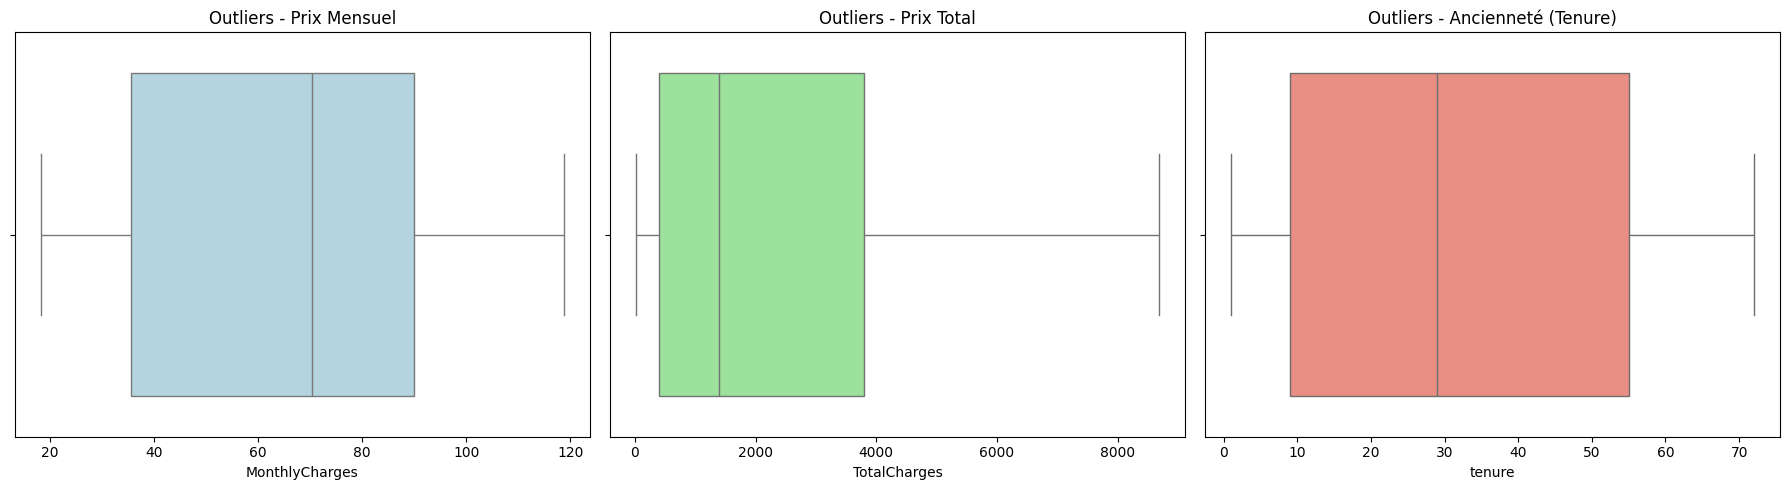

In [15]:
# On augmente un peu la largeur (18 au lieu de 12) pour que les 3 soient bien lisibles
plt.figure(figsize=(18, 5))

# 1. Boxplot pour les charges mensuelles (Grille 1x3, Position 1)
plt.subplot(1, 3, 1)
sns.boxplot(x=df['MonthlyCharges'], color='lightblue')
plt.title('Outliers - Prix Mensuel')

# 2. Boxplot pour le total payé (Grille 1x3, Position 2)
plt.subplot(1, 3, 2)
sns.boxplot(x=df['TotalCharges'], color='lightgreen')
plt.title('Outliers - Prix Total')

# 3. Boxplot pour l'ancienneté (Grille 1x3, Position 3)
plt.subplot(1, 3, 3)
sns.boxplot(x=df['tenure'], color='salmon')
plt.title('Outliers - Ancienneté (Tenure)')

plt.tight_layout()
plt.show()

### EDA-5 Visualisations
Nous souhaitons faire des visualisations pour essayer comprendre ce qui pousse un client au désabonnement

C:\Users\thoma\AppData\Local\Temp\ipykernel_17816\1045986789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


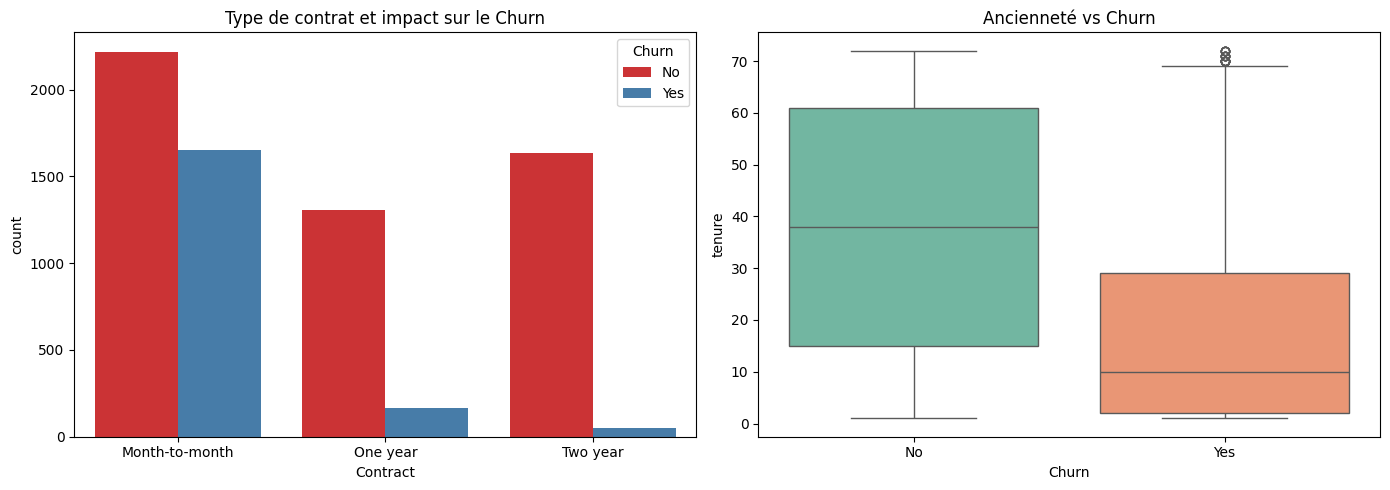

In [16]:
plt.figure(figsize=(14, 5))

# 1er Graphique : L'impact du type de contrat
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Type de contrat et impact sur le Churn')

# 2ème Graphique : Impact de l'ancienneté
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Ancienneté vs Churn')

plt.tight_layout()
plt.show()


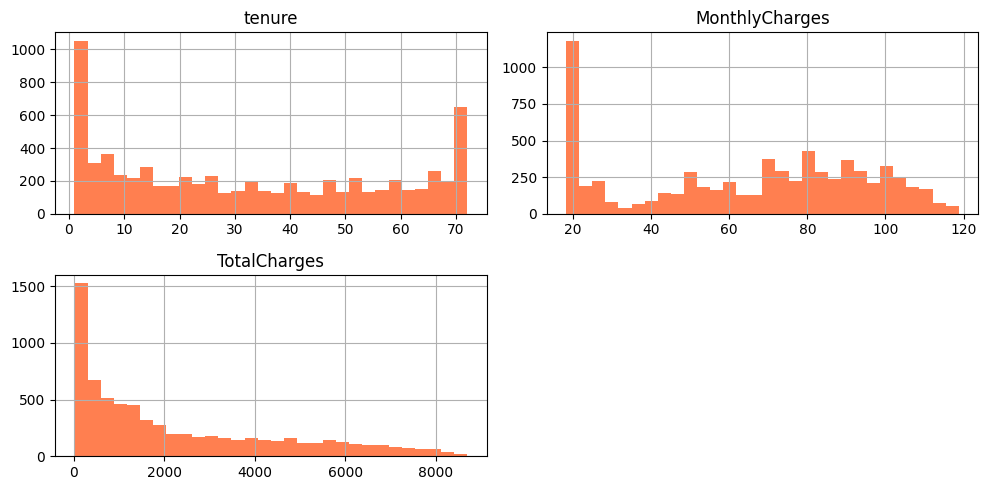

In [17]:
# Histogrammes pour analyser les distributions
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(10, 5), color='coral')
plt.tight_layout()
plt.show()

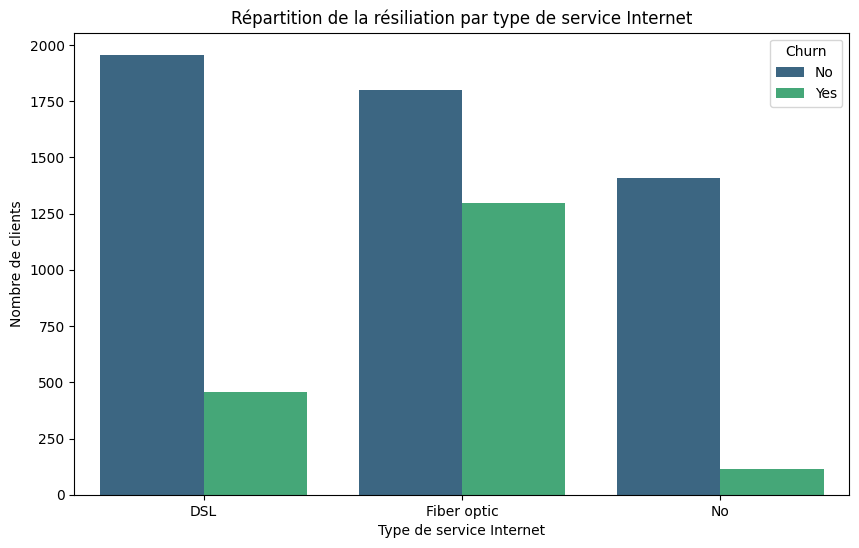

In [18]:
plt.figure(figsize=(10, 6))
# On crée un graphique à barres montrant le nombre de clients par service, coloré par Churn
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')

plt.title('Répartition de la résiliation par type de service Internet')
plt.xlabel('Type de service Internet')
plt.ylabel('Nombre de clients')
plt.show()

### EDA-6 - Corrélations
Matrice des corrélations pour vérifier des liens mathématiques entre nos variables numériques.

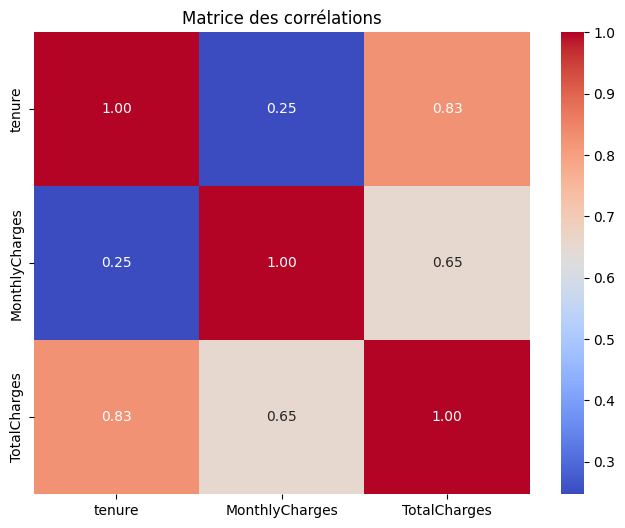

In [19]:
plt.figure(figsize=(8, 6))

# On isole uniquement les colonnes avec des nombres pour ce calcul
donnees_numeriques = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# On génère la carte des corrélations (heatmap)
sns.heatmap(donnees_numeriques.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice des corrélations')
plt.show()

Chi2 et Cramér

In [20]:
import scipy.stats as stats

# Fonction pour calculer le Chi2 et le V de Cramer
def analyse_cramer(colonne_etudiee, cible='Churn'):
    confusion_matrix = pd.crosstab(df[colonne_etudiee], df[cible])
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)

    # Calcul du V de Cramer
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim))

    print(f"--- {colonne_etudiee} vs {cible} ---")
    print(f"p-value (Chi²) : {p:.5f}")
    print(f"V de Cramér : {v_cramer:.5f}\n")

# On teste 3 variables catégorielles par rapport au Churn
analyse_cramer('Contract')
analyse_cramer('InternetService')
analyse_cramer('gender')

--- Contract vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.40956

--- InternetService vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.32191

--- gender vs Churn ---
p-value (Chi²) : 0.49049
V de Cramér : 0.00822

